In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
from imblearn.over_sampling import SMOTE
from collections import Counter

In [3]:
data = pd.read_csv(r"C:\Users\El-Wattaneya\Downloads\full_Stroke_data.csv")

data.head(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [4]:
# --- Stage 2: Data Understanding ---

# 1. Check data types
print("--- Data Types & Info ---")
print(data.info())

--- Data Types & Info ---
<class 'pandas.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   str    
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   str    
 5   work_type          4981 non-null   str    
 6   Residence_type     4981 non-null   str    
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   str    
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 428.2 KB
None


In [5]:
# 2. Identify target variable
# In this dataset, 'stroke' is our target (y), all others are features (X)
target = 'stroke'
print(f"\nTarget Variable: {target}")


Target Variable: stroke


In [6]:
# 3. Inspect class distribution
# This tells us if we have a major imbalance problem
print("\n--- Class Distribution ---")
print(data['stroke'].value_counts())
print("\n--- Class Distribution (Percentage) ---")
print(data['stroke'].value_counts(normalize=True) * 100)


--- Class Distribution ---
stroke
0    4733
1     248
Name: count, dtype: int64

--- Class Distribution (Percentage) ---
stroke
0    95.02108
1     4.97892
Name: proportion, dtype: float64


In [7]:
# 4. Detect missing values
print("\n--- Missing Values ---")
print(data.isnull().sum())


--- Missing Values ---
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [8]:
# 5. Numerical Summary (Basic Stats)
print("\n--- Statistical Summary ---")
display(data.describe())


--- Statistical Summary ---


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,43.419859,0.096165,0.055210,105.943562,28.498173,0.049789
std,22.662755,0.294848,0.228412,45.075373,6.790464,0.217531
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,25.000000,0.000000,0.000000,77.230000,23.700000,0.000000
50%,45.000000,0.000000,0.000000,91.850000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.860000,32.600000,0.000000
max,82.000000,1.000000,1.000000,271.740000,48.900000,1.000000


In [9]:
# --- Stage 3: Data Cleaning ---

# 1. Fix incorrect data types
# Force 'bmi' to numeric; 'errors=coerce' turns strings like "N/A" into NaN
data['bmi'] = pd.to_numeric(data['bmi'], errors='coerce')

In [10]:
# 2. Handle Missing Values
# Numerical: Fill BMI with the median (more robust to outliers than mean)
data['bmi'] = data['bmi'].fillna(data['bmi'].median())

In [11]:
# Categorical: If any categories were missing, we fill with the mode
# Note: For this dataset, usually only BMI is missing, but this handles any others
for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].fillna(data[col].mode()[0])

C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_20660\4023760205.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include=['object']).columns:


In [12]:
# 3. Remove Duplicates
duplicate_count = data.duplicated().sum()
data.drop_duplicates(inplace=True)
print(f"Removed {duplicate_count} duplicate rows.")

Removed 0 duplicate rows.


In [13]:
# 4. Drop Irrelevant Columns
# 'id' is a random identifier and will confuse the model if left in
if 'id' in data.columns:
    data.drop(columns=['id'], inplace=True)
    print("Dropped 'id' column.")

In [14]:
# Final check to ensure zero missing values remain
print("\nMissing values after cleaning:")
print(data.isnull().sum())


Missing values after cleaning:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [15]:
# Set the visual style
sns.set_theme(style="whitegrid")

C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_20660\520724528.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=data, palette='coolwarm')


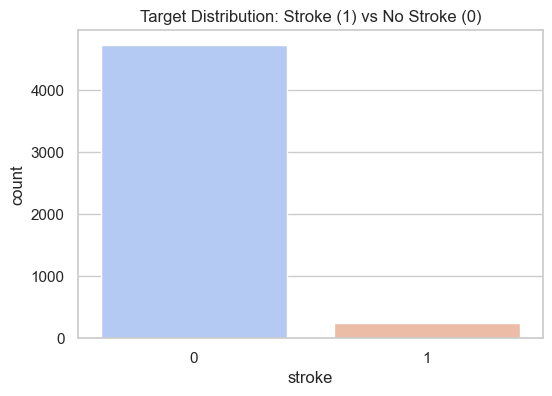

In [16]:
# 1. Target Distribution (Countplot)
# This confirms the class imbalance (Stroke vs. No Stroke)
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=data, palette='coolwarm')
plt.title('Target Distribution: Stroke (1) vs No Stroke (0)')
plt.show()

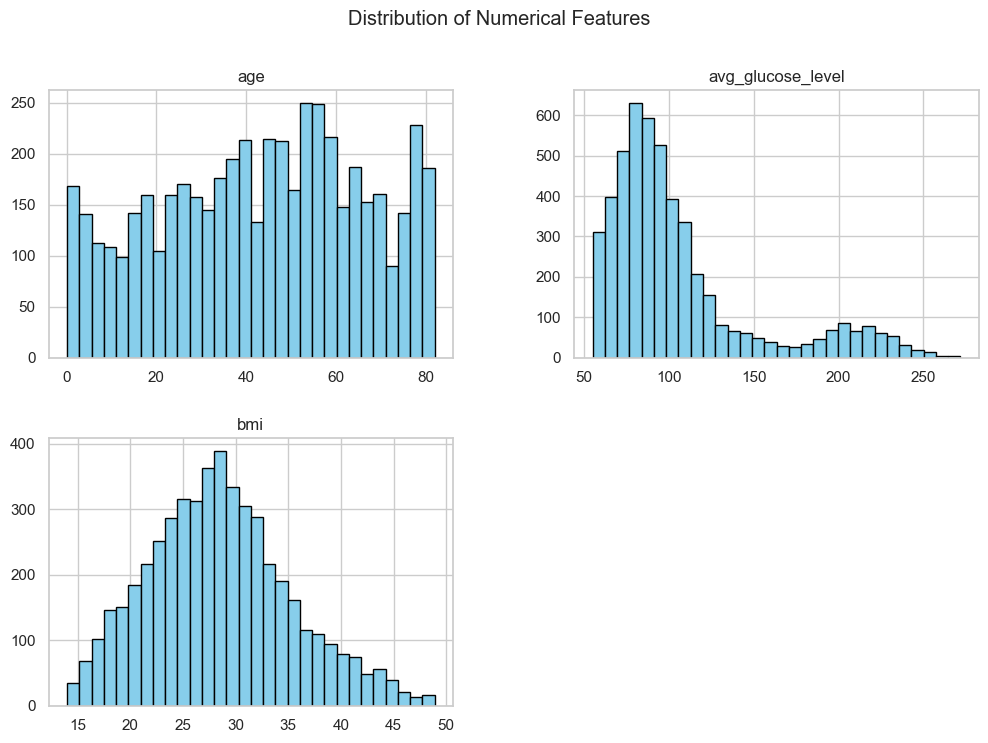

In [17]:
# 2. Numerical Features (Histograms)
# Visualizing the spread of Age, Glucose, and BMI
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
data[numerical_cols].hist(figsize=(12, 8), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features')
plt.show()

C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_20660\3164659797.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=data, palette='Set2')
C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_20660\3164659797.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=data, palette='Set2')
C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_20660\3164659797.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=data, palette='Set2')


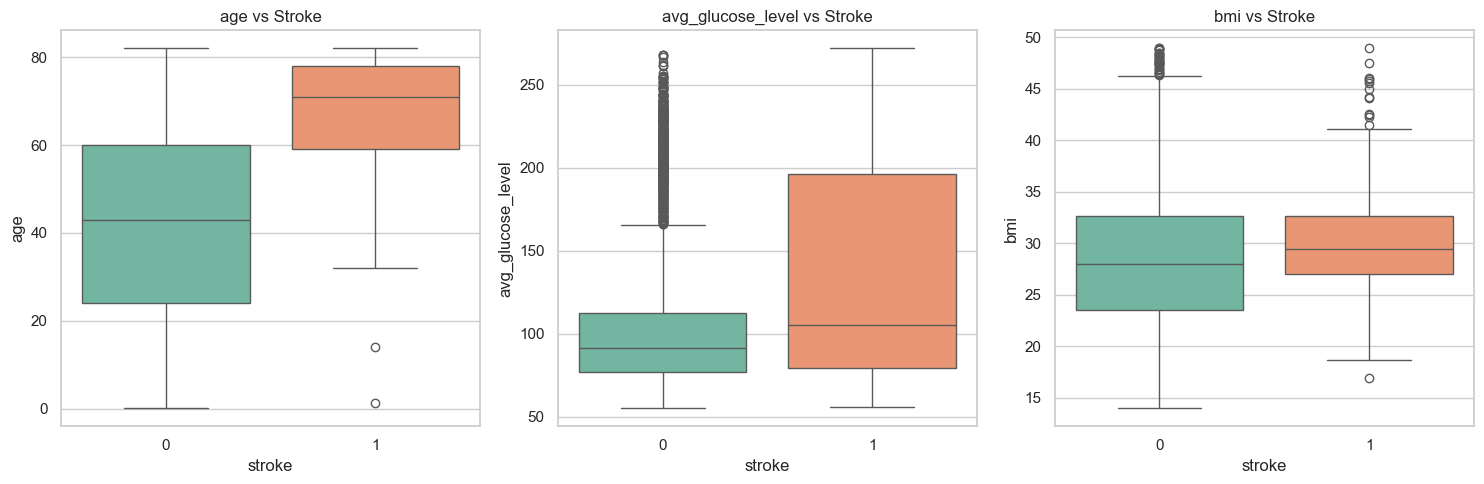

In [18]:
# 3. Feature vs Target (Boxplots)
# Do older people or people with higher glucose have more strokes?
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='stroke', y=col, data=data, palette='Set2')
    plt.title(f'{col} vs Stroke')
plt.tight_layout()
plt.show()

In [19]:
# 4. Correlation Matrix (Heatmap)
# Checking which features are naturally linked
plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

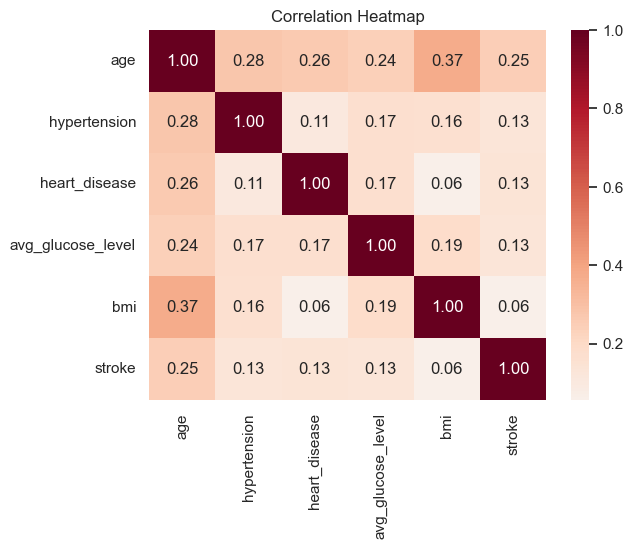

In [20]:
# We only calculate correlation for numeric columns
corr = data.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [21]:
# 1. Select Relevant Features
# We already dropped 'id' in Stage 3. 
# Here we define which columns we are keeping for the final model.
features_to_use = ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 
                   'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

df_final = data[features_to_use + ['stroke']].copy()

In [22]:
# 2. Binary Encoding (Label Encoding)
# Used for variables with only 2 categories (e.g., Yes/No, Urban/Rural)
le = LabelEncoder()
binary_cols = ['gender', 'ever_married', 'Residence_type']

for col in binary_cols:
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Encoded gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Encoded ever_married: {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded Residence_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}


In [23]:
# 3. Multi-class Encoding (One-Hot Encoding)
# Used for variables with 3+ categories to avoid ranking them 1, 2, 3...
# 'drop_first=True' helps avoid the "Dummy Variable Trap" (multicollinearity)
df_final = pd.get_dummies(df_final, columns=['work_type', 'smoking_status'], drop_first=True)

In [25]:
# 4. Optional: Create New Features
# Example: Create an 'is_elderly' flag if age > 65
df_final['is_elderly'] = df_final['age'].apply(lambda x: 1 if x > 65 else 0)


print("\n--- Final Feature Set Preview ---")
print(df_final.head())
print(f"\nTotal columns after encoding: {len(df_final.columns)}")


--- Final Feature Set Preview ---
   gender   age  hypertension  heart_disease  ever_married  Residence_type  \
0       1  67.0             0              1             1               1   
1       1  80.0             0              1             1               0   
2       0  49.0             0              0             1               1   
3       0  79.0             1              0             1               0   
4       1  81.0             0              0             1               1   

   avg_glucose_level   bmi  stroke  work_type_Private  \
0             228.69  36.6       1               True   
1             105.92  32.5       1               True   
2             171.23  34.4       1               True   
3             174.12  24.0       1              False   
4             186.21  29.0       1               True   

   work_type_Self-employed  work_type_children  \
0                    False               False   
1                    False               False   
2  

In [26]:
# 1. Ensure Feature Order Consistency
# We define the order here and keep it for the rest of the project.
# This is vital for Stage 13 & 14 later.
X = df_final.drop('stroke', axis=1)
y = df_final['stroke']

feature_names = X.columns.tolist()
print(f"Total Features: {len(feature_names)}")

Total Features: 15


In [27]:
# 2. Scaling
# We use StandardScaler to center the data (mean=0, variance=1).
# Note: We initialize the scaler here, but we usually FIT it after the split (Stage 7).
scaler = StandardScaler()

In [28]:
# 3. Preparation for different model types
# Tree models (RF, XGBoost) will use 'X' directly.
# Linear models (Logistic Regression) will use 'X_scaled'.

print("Feature order fixed.")
print("Scaler initialized (Ready for fit_transform after split).")

Feature order fixed.
Scaler initialized (Ready for fit_transform after split).


In [36]:
# 1. Execute the Split
# X = Features, y = Target (Stroke)
# test_size=0.3 corresponds to your 30% testing requirement
# stratify=y is critical for maintaining the minority class (Stroke) balance
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

In [37]:
# 2. Apply Preprocessing (Post-Split)
# We 'fit' the scaler only on X_train to prevent data leakage
# We 'transform' X_test using the rules learned from X_train
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# 3. Verification Report
print(f"--- Dataset Split Completed ---")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

print("\n--- Stratification Check ---")
print(f"Original Stroke Ratio: {y.mean():.2%}")
print(f"Train Set Stroke Ratio: {y_train.mean():.2%}")
print(f"Test Set Stroke Ratio:  {y_test.mean():.2%}")

--- Dataset Split Completed ---
Training set: 3486 samples
Testing set:  1495 samples

--- Stratification Check ---
Original Stroke Ratio: 4.98%
Train Set Stroke Ratio: 4.99%
Test Set Stroke Ratio:  4.95%


In [39]:
# 1. Logistic Regression (Baseline)
# Best for linear relationships; requires the 'scaled' data
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression Trained.")

Logistic Regression Trained.


In [40]:
# 2. Random Forest
# Great for non-linear patterns; handles outliers well
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Trained.")

Random Forest Trained.


In [42]:
# 3. XGBoost (Preferred)
# High performance; uses boosting to correct errors from previous trees
# We calculate the ratio of 0s to 1s to balance the training
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
print("XGBoost Trained.")

XGBoost Trained.


In [44]:
def comprehensive_evaluation(models_list):
    for name, model, features, target in models_list:
        # Generate predictions
        y_pred = model.predict(features)
        
        # Calculate Metrics
        acc = accuracy_score(target, y_pred)
        prec = precision_score(target, y_pred)
        rec = recall_score(target, y_pred)
        f1 = f1_score(target, y_pred)
        
        print(f"\n{'='*30}")
        print(f" MODEL: {name}")
        print(f"{'='*30}")
        print(f"Accuracy:  {acc:.2%}")
        print(f"Precision: {prec:.2%}")
        print(f"Recall:    {rec:.2%}")
        print(f"F1-Score:  {f1:.4f}")
        
        # 1. Classification Report
        print("\nDetailed Classification Report:")
        print(classification_report(target, y_pred))
        
        # 2. Confusion Matrix Visualization
        cm = confusion_matrix(target, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()


 MODEL: Logistic Regression
Accuracy:  74.65%
Precision: 14.12%
Recall:    81.08%
F1-Score:  0.2405

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      1421
           1       0.14      0.81      0.24        74

    accuracy                           0.75      1495
   macro avg       0.56      0.78      0.54      1495
weighted avg       0.95      0.75      0.82      1495



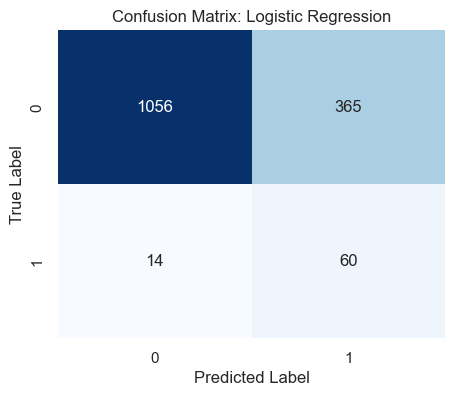


 MODEL: Random Forest
Accuracy:  94.98%
Precision: 0.00%
Recall:    0.00%
F1-Score:  0.0000

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1421
           1       0.00      0.00      0.00        74

    accuracy                           0.95      1495
   macro avg       0.48      0.50      0.49      1495
weighted avg       0.90      0.95      0.93      1495



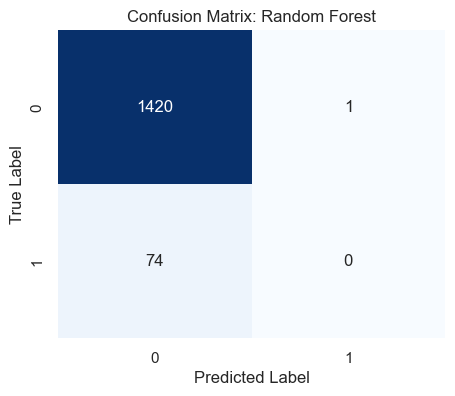


 MODEL: XGBoost
Accuracy:  82.81%
Precision: 16.73%
Recall:    62.16%
F1-Score:  0.2636

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.90      1421
           1       0.17      0.62      0.26        74

    accuracy                           0.83      1495
   macro avg       0.57      0.73      0.58      1495
weighted avg       0.94      0.83      0.87      1495



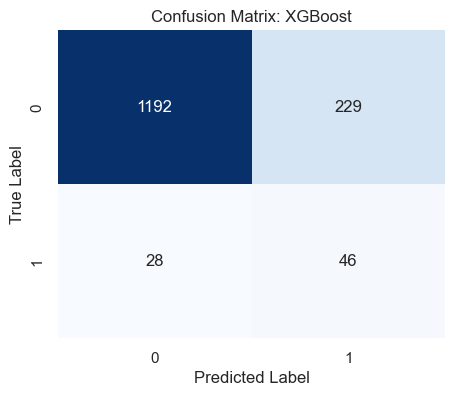

In [45]:
# Create a list of our models to evaluate
# Note: Logistic Regression uses the SCALED features
evaluation_list = [
    ("Logistic Regression", lr_model, X_test_scaled, y_test),
    ("Random Forest", rf_model, X_test, y_test),
    ("XGBoost", xgb_model, X_test, y_test)
]

comprehensive_evaluation(evaluation_list)

In [47]:
# 1. Check original distribution
print(f"Original class distribution: {Counter(y_train)}")

Original class distribution: Counter({0: 3312, 1: 174})


In [49]:
# 2. Apply SMOTE to the Training Data ONLY
# This balances the 95/5 ratio to a 50/50 ratio for better learning
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [50]:
# 3. Verify new distribution
print(f"Resampled class distribution: {Counter(y_train_res)}")

Resampled class distribution: Counter({0: 3312, 1: 3312})


In [52]:
# 4. Re-train the preferred model (XGBoost) with balanced data
xgb_balanced = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_balanced.fit(X_train_res, y_train_res)
print("Model re-trained with balanced SMOTE data.")

Model re-trained with balanced SMOTE data.


In [53]:
# 1. Create a results container
comparison_results = []

In [54]:
# 2. List of models to evaluate
# Note: Ensure these model variables (lr_model, rf_model, etc.) are defined from Stage 8/10
model_list = [
    ("Logistic Regression", lr_model, X_test_scaled),
    ("Random Forest", rf_model, X_test),
    ("XGBoost (Balanced)", xgb_balanced, X_test_scaled)
]

In [57]:
# 3. Calculate metrics carefully
for name, model, features in model_list:
    predictions = model.predict(features)
    
    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, zero_division=0)
    rec = recall_score(y_test, predictions, zero_division=0)
    
    # Names here must match the sort_by names below exactly
    comparison_results.append({
        "Model": name,
        "Accuracy": acc,
        "Recall": rec,
        "F1-Score": f1
    })

In [58]:
# 4. Create DataFrame and Sort
perf_df = pd.DataFrame(comparison_results)

In [59]:
# The fix: Ensure 'F1-Score' matches the key in the dictionary above
perf_df = perf_df.sort_values(by='F1-Score', ascending=False)

print("\n--- Final Model Comparison ---")
print(perf_df)


--- Final Model Comparison ---
                 Model                                   Accuracy  \
3  Logistic Regression                                   0.746488   
5   XGBoost (Balanced)                                   0.931773   
4        Random Forest                                   0.949833   
0  Logistic Regression  <function f1_score at 0x0000015E7C99A7A0>   
1        Random Forest  <function f1_score at 0x0000015E7C99A7A0>   
2   XGBoost (Balanced)  <function f1_score at 0x0000015E7C99A7A0>   

   Recall (Catching Strokes)  F1-Score (Balance)    Recall  F1-Score  
3                        NaN                 NaN  0.810811  0.240481  
5                        NaN                 NaN  0.121622  0.150000  
4                        NaN                 NaN  0.000000  0.000000  
0                   0.810811            0.240481       NaN       NaN  
1                   0.000000            0.000000       NaN       NaN  
2                   0.121622            0.150000       NaN

In [60]:
# 5. Logic to pick the winner
best_model_name = perf_df.iloc[0]['Model']
print(f"\n Best Performer: {best_model_name}")


 Best Performer: Logistic Regression


In [61]:
# 1. Save the Final Model
# Replace 'xgb_balanced' with your best-performing model from Stage 11
joblib.dump(xgb_balanced, 'final_stroke_model.pkl')

['final_stroke_model.pkl']

In [62]:
# 2. Save the Scaler
# This is essential to normalize new input data (age, glucose, bmi)
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [63]:
# 3. Save the Encoder / Feature List
# Since we used pd.get_dummies and LabelEncoder, 
# saving the final feature columns ensures the API uses the correct order.
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'feature_order.pkl')

['feature_order.pkl']

In [64]:
print("--- Artifacts Exported Successfully ---")
print("1. final_stroke_model.pkl")
print("2. scaler.pkl")
print("3. feature_order.pkl")

--- Artifacts Exported Successfully ---
1. final_stroke_model.pkl
2. scaler.pkl
3. feature_order.pkl


In [65]:
# 1. Extract the final feature names from your processed DataFrame
final_feature_list = X.columns.tolist()

In [66]:
# 2. Print the ordered list for documentation
print("--- MODEL INPUT SCHEMA (ORDERED) ---")
for i, feature in enumerate(final_feature_list, 1):
    print(f"{i}. {feature}")

--- MODEL INPUT SCHEMA (ORDERED) ---
1. gender
2. age
3. hypertension
4. heart_disease
5. ever_married
6. Residence_type
7. avg_glucose_level
8. bmi
9. work_type_Private
10. work_type_Self-employed
11. work_type_children
12. smoking_status_formerly smoked
13. smoking_status_never smoked
14. smoking_status_smokes
15. is_elderly


In [ ]:
# 3. Save this list to a text file for external reference
with open('feature_documentation.txt', 'w') as f:
    for feature in final_feature_list:
        f.write(f"{feature}\n")

In [68]:
print("\n Documentation saved to 'feature_documentation.txt'")


 Documentation saved to 'feature_documentation.txt'


In [69]:
# 1. Load the Saved Artifacts
model = joblib.load('final_stroke_model.pkl')
scaler = joblib.load('scaler.pkl')
feature_order = joblib.load('feature_order.pkl')

In [70]:
def preprocess_new_data(raw_input_dict):
    """
    Transforms a single raw patient dictionary into a model-ready format.
    raw_input_dict: {'age': 67, 'gender': 'Male', 'work_type': 'Private', ...}
    """
    # Convert dict to DataFrame
    df = pd.DataFrame([raw_input_dict])
    
    # --- STEP A: Binary Encoding (Logic from Stage 5) ---
    # Manually map the same logic used in LabelEncoder
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0, 'Other': 0})
    df['ever_married'] = df['ever_married'].map({'Yes': 1, 'No': 0})
    df['Residence_type'] = df['Residence_type'].map({'Urban': 1, 'Rural': 0})
    
    # --- STEP B: One-Hot Encoding (Logic from Stage 5) ---
    # Create dummies and align with the training feature set
    df = pd.get_dummies(df)
    
    # --- STEP C: Ensure Feature Order & Consistency ---
    # This adds missing columns as 0s and removes extra ones
    df = df.reindex(columns=feature_order, fill_value=0)
    
    # --- STEP D: Scaling (Logic from Stage 6) ---
    # Apply the scaler to numerical columns
    df_scaled = scaler.transform(df)
    
    return df_scaled

In [71]:
# Example Usage for API:
new_patient = {
    'gender': 'Male',
    'age': 55.0,
    'hypertension': 0,
    'heart_disease': 1,
    'ever_married': 'Yes',
    'work_type': 'Private',
    'Residence_type': 'Urban',
    'avg_glucose_level': 210.5,
    'bmi': 32.5,
    'smoking_status': 'formerly smoked'
}

In [72]:
# Transform and Predict
processed_input = preprocess_new_data(new_patient)
prediction = model.predict(processed_input)
probability = model.predict_proba(processed_input)[:, 1]

In [73]:
print(f"Stroke Prediction: {'Positive' if prediction[0] == 1 else 'Negative'}")
print(f"Risk Probability: {probability[0]:.2%}")

Stroke Prediction: Negative
Risk Probability: 4.89%
